<a href="https://colab.research.google.com/github/Samra-younas/AI_Machine_Learning/blob/main/Heart_disease_classifier_by_decision_tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Heart disease data deision tree classiifer

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
import matplotlib.pyplot as plt

df = pd.read_csv("/content/heart_disease_data.csv")
df.head()


,age,sex,cp(chest pain),trestbps,chol(chol),fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,48,1,0,130,256,1,0,150,1,0.0,2,2,3,0
1,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
2,44,0,2,118,242,0,1,149,0,0.3,1,1,2,1
3,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
4,56,1,3,120,193,0,0,162,0,1.9,1,0,3,1


prepare the feature and target

In [ ]:
print(df.columns)


Index(['age', 'sex', 'cp(chest pain)', 'trestbps', 'chol(chol)', 'fbs',
       'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal',
       'target'],
      dtype='object')


In [ ]:
x = df.drop(columns = ['target'])
y = df['target']

In [ ]:
X_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.3,random_state=42)

# Initialize and train the decision tree model
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.9230769230769231
Confusion Matrix:
 [[74  8]
 [ 6 94]]
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.90      0.91        82
           1       0.92      0.94      0.93       100

    accuracy                           0.92       182
   macro avg       0.92      0.92      0.92       182
weighted avg       0.92      0.92      0.92       182



# Using hyperparameter grid on heart disease dataset

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score



In [ ]:
df = pd.read_csv("/content/heart_disease_data.csv")

#Feature and target
x = df.drop(columns = ['target'])
y = df['target']

In [ ]:
x = df.drop(columns=['target'])
y = df['target']

print(x)
print(y)


     age  sex  cp(chest pain)  trestbps  chol(chol)  fbs  restecg  thalach  \
0     48    1               0       130         256    1        0      150   
1     61    1               0       148         203    0        1      161   
2     44    0               2       118         242    0        1      149   
3     47    1               0       110         275    0        0      118   
4     56    1               3       120         193    0        0      162   
..   ...  ...             ...       ...         ...  ...      ...      ...   
601   60    1               2       140         185    0        0      155   
602   67    0               2       115         564    0        0      160   
603   40    1               3       140         199    0        1      178   
604   50    0               0       110         254    0        0      159   
605   62    1               1       120         281    0        0      103   

     exang  oldpeak  slope  ca  thal  
0        1      0.0     

In [ ]:
# Split the data into training and testing sets
X_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

In [ ]:
#define the model
model = DecisionTreeClassifier(random_state=42)
print(model)



DecisionTreeClassifier(random_state=42)


In [ ]:
#define the hyperparameter grid for Decision tree
param_grid = param_grid = {
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt', 'log2']
}
#print(param_grid)

{'max_depth': [None, 10, 20, 30], 'min_samples_split': [2, 5, 10], 'min_samples_leaf': [1, 2, 4], 'max_features': ['auto', 'sqrt', 'log2']}


In [ ]:
#set up grid search cv
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, scoring='accuracy')

print(grid_search)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42),
             param_grid={'max_depth': [None, 10, 20, 30],
                         'max_features': ['auto', 'sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10]},
             scoring='accuracy')


In [ ]:
#fit the grid search to the training data

grid_search.fit(X_train,y_train)

print(grid_search.fit)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
<bound method BaseSearchCV.fit of GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20, 30],
                         'max_features': ['auto', 'sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10]},
             verbose=2)>


In [ ]:
#get the best parameter and model

print(f"Best parameter: {grid_search.best_params_}")
best_model = grid_search.best_estimator_

#print(best_model)

Best parameter: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2}


In [ ]:
# Make predictions on the test set
y_pred = best_model.predict(X_test)

# Calculate the accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 96.72%


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Load the dataset
df = pd.read_csv("/content/heart_disease_data.csv")

# Features and target
X = df.drop(columns=['target'])  # All columns except 'target'
y = df['target']  # Target column

# Split the dataset into training and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the model (Decision Tree)
model = DecisionTreeClassifier(random_state=42)

# Define the hyperparameters grid for Decision Tree
param_grid = {
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt', 'log2']
}

# Set up GridSearchCV
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)

# Fit the grid search to the training data
grid_search.fit(X_train, y_train)

# Get the best parameters and model
print(f"Best parameters: {grid_search.best_params_}")
best_model = grid_search.best_estimator_

# Check the type of the best_model
print(f"Type of best_model: {type(best_model)}")

# Make predictions on the test set
y_pred = best_model.predict(X_test)

# Calculate the accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")
print(X_test)
prin


Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2}
Type of best_model: <class 'sklearn.tree._classes.DecisionTreeClassifier'>
Accuracy: 96.72%
     age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
572   44    1   0       110   197    0        0      177      0      0.0   
289   69    0   3       140   239    0        1      151      0      1.8   
76    44    1   2       130   233    0        1      179      1      0.4   
78    57    1   1       154   232    0        0      164      0      0.0   
182   76    0   2       140   197    0        2      116      0      1.1   
..   ...  ...  ..       ...   ...  ...      ...      ...    ...      ...   
249   71    0   0       112   149    0        1      125      0      1.6   
365   57    1   2       128   229    0        0      150      0      0.4   
452   61    0   0       145   307    0        0      

/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
180 fits failed out of a total of 540.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
180 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.11/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.11/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.11/dist-packages/sklearn/util

# use one hot encoding

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Load the dataset
df = pd.read_csv("/content/heart_disease_data.csv")

# Identify categorical columns
# For demonstration, let's assume 'gender' and 'chest_pain' are categorical (you should check the actual columns of your dataset)
categorical_columns = ['sex', 'cp(chest pain)']  # Example; replace with actual categorical columns in your dataset

# Apply one-hot encoding to categorical columns
df_encoded = pd.get_dummies(df, columns=categorical_columns, drop_first=True)  # drop_first=True avoids multicollinearity

# Features and target
X = df_encoded.drop(columns=['target'])  # All columns except 'target'
y = df_encoded['target']  # Target column

# Split the dataset into training and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the model (Decision Tree)
model = DecisionTreeClassifier(random_state=42)

# Define the hyperparameters grid for Decision Tree
param_grid = {
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt', 'log2']
}

# Set up GridSearchCV
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)

# Fit the grid search to the training data
grid_search.fit(X_train, y_train)

# Get the best parameters and model
print(f"Best parameters: {grid_search.best_params_}")
best_model = grid_search.best_estimator_

# Check the type of the best_model
print(f"Type of best_model: {type(best_model)}")

# Make predictions on the test set
y_pred = best_model.predict(X_test)

# Calculate the accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")


Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2}
Type of best_model: <class 'sklearn.tree._classes.DecisionTreeClassifier'>
Accuracy: 96.72%


# use label encoding

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

# Load the dataset
df = pd.read_csv("/content/heart_disease_data.csv")

# Identify categorical columns
# For demonstration, let's assume 'gender' and 'chest_pain' are categorical (you should check the actual columns of your dataset)
categorical_columns = ['sex', 'cp(chest pain)']  # Replace these with the correct categorical columns from your dataset

# Initialize the LabelEncoder
label_encoder = LabelEncoder()

# Apply label encoding to the categorical columns
for col in categorical_columns:
    df[col] = label_encoder.fit_transform(df[col])

# Features and target
X = df.drop(columns=['target'])  # All columns except 'target'
y = df['target']  # Target column

# Split the dataset into training and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the model (Decision Tree)
model = DecisionTreeClassifier(random_state=42)

# Define the hyperparameters grid for Decision Tree
param_grid = {
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt', 'log2']
}

# Set up GridSearchCV
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)

# Fit the grid search to the training data
grid_search.fit(X_train, y_train)

# Get the best parameters and model
print(f"Best parameters: {grid_search.best_params_}")
best_model = grid_search.best_estimator_

# Check the type of the best_model
print(f"Type of best_model: {type(best_model)}")

# Make predictions on the test set
y_pred = best_model.predict(X_test)

# Calculate the accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")


Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2}
Type of best_model: <class 'sklearn.tree._classes.DecisionTreeClassifier'>
Accuracy: 96.72%


In [ ]:
print(df.columns)

Index(['age', 'sex', 'cp(chest pain)', 'trestbps', 'chol(chol)', 'fbs',
       'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal',
       'target'],
      dtype='object')


# Apply decision tree with random forest on heart data to check accuracy


In [ ]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix

# Load the dataset
df = pd.read_csv("/content/heart_disease_data.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,48,1,0,130,256,1,0,150,1,0.0,2,2,3,0
1,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
2,44,0,2,118,242,0,1,149,0,0.3,1,1,2,1
3,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
4,56,1,3,120,193,0,0,162,0,1.9,1,0,3,1


# Load and preprocess data

In [ ]:

df['age'].fillna(df['age'].median(), inplace=True)
df['sex'] = df['sex'].map({'male': 0, 'female': 1})
df['exang'] = df['exang'].map({'S': 0, 'C': 1, 'Q': 2})
df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1, inplace=True)

# Define features (X) and target variable (y)
X = df.drop('Survived', axis=1)
y = df['Survived']

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


<ipython-input-20-e8daaa8d97f0>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].median(), inplace=True)


KeyError: "['PassengerId', 'Name', 'Ticket', 'Cabin'] not found in axis"

In [ ]:
# Import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Sample data
data = {
    'age': [48, 61, 44, 47, 56],
    'sex': [1, 1, 0, 1, 1],
    'cp': [0, 0, 2, 0, 3],
    'trestbps': [130, 148, 118, 110, 120],
    'chol': [256, 203, 242, 275, 193],
    'fbs': [1, 0, 0, 0, 0],
    'restecg': [0, 1, 1, 0, 0],
    'thalach': [150, 161, 149, 118, 162],
    'exang': [1, 0, 0, 1, 0],
    'oldpeak': [0.0, 0.0, 0.3, 1.0, 1.9],
    'slope': [2, 2, 1, 1, 1],
    'ca': [2, 1, 1, 1, 0],
    'thal': [3, 3, 2, 2, 3],
    'target': [0, 0, 1, 0, 1]
}

# Convert the data to DataFrame
df = pd.DataFrame(data)

# Split the data into features (X) and target (y)
X = df.drop('target', axis=1)
y = df['target']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the models
decision_tree = DecisionTreeClassifier(random_state=42)
random_forest = RandomForestClassifier(random_state=42)

# Train the Decision Tree model
decision_tree.fit(X_train, y_train)

# Train the Random Forest model
random_forest.fit(X_train, y_train)

# Make predictions
y_pred_dt = decision_tree.predict(X_test)
y_pred_rf = random_forest.predict(X_test)

# Evaluate the models
print("Decision Tree Classifier Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt)}")
print("Classification Report:")
print(classification_report(y_test, y_pred_dt))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

print("\nRandom Forest Classifier Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf)}")
print("Classification Report:")
print(classification_report(y_test, y_pred_rf))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))


Decision Tree Classifier Evaluation:
Accuracy: 0.0
Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       1.0
           1       0.00      0.00      0.00       0.0

    accuracy                           0.00       1.0
   macro avg       0.00      0.00      0.00       1.0
weighted avg       0.00      0.00      0.00       1.0

Confusion Matrix:
[[0 1]
 [0 0]]

Random Forest Classifier Evaluation:
Accuracy: 0.0
Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       1.0
           1       0.00      0.00      0.00       0.0

    accuracy                           0.00       1.0
   macro avg       0.00      0.00      0.00       1.0
weighted avg       0.00      0.00      0.00       1.0

Confusion Matrix:
[[0 1]
 [0 0]]


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   48    1   0       130   256    1        0      150      1      0.0      2   
1   61    1   0       148   203    0        1      161      0      0.0      2   
2   44    0   2       118   242    0        1      149      0      0.3      1   
3   47    1   0       110   275    0        0      118      1      1.0      1   
4   56    1   3       120   193    0        0      162      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   1     3       0  
2   1     2       1  
3   1     2       0  
4   0     3       1  
Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')
Decision Tree Classifier Evaluation:
Accuracy: 0.9672131147540983
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.92      0.96        50
           1       0.95 

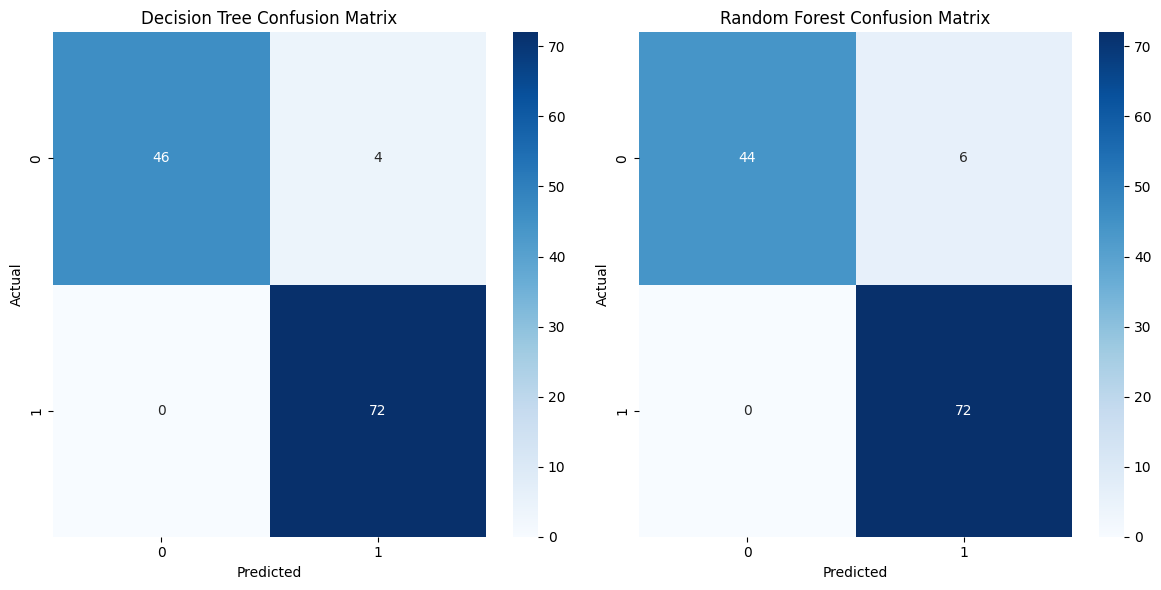

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset from CSV
df = pd.read_csv("/content/heart_disease_data.csv")

# Print the first few rows to inspect the dataset
print(df.head())

# Print column names to verify if there are any discrepancies
print(df.columns)

# Optional: If needed, you can rename columns or perform any preprocessing here
# For example, handle missing values
df.fillna(df.mean(), inplace=True)  # You can also use other strategies like median or mode

# Map categorical columns to numeric values if necessary
# Example: If you have a column 'sex' with 'male' and 'female' values, map them to 0 and 1
# df['sex'] = df['sex'].map({'male': 0, 'female': 1})  # Adjust based on your dataset

# Define features (X) and target variable (y)
X = df.drop('target', axis=1)  # Assuming the target column is 'target'
y = df['target']  # Assuming the target column is 'target'

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the models
decision_tree = DecisionTreeClassifier(random_state=42)
random_forest = RandomForestClassifier(random_state=42)

# Train the Decision Tree model
decision_tree.fit(X_train, y_train)

# Train the Random Forest model
random_forest.fit(X_train, y_train)

# Make predictions
y_pred_dt = decision_tree.predict(X_test)
y_pred_rf = random_forest.predict(X_test)

# Evaluate the models
print("Decision Tree Classifier Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt)}")
print("Classification Report:")
print(classification_report(y_test, y_pred_dt))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

print("\nRandom Forest Classifier Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf)}")
print("Classification Report:")
print(classification_report(y_test, y_pred_rf))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

# Plotting the confusion matrix for visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Decision Tree Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Decision Tree Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Random Forest Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title('Random Forest Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()


Dataset preview:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   48    1   0       130   256    1        0      150      1      0.0      2   
1   61    1   0       148   203    0        1      161      0      0.0      2   
2   44    0   2       118   242    0        1      149      0      0.3      1   
3   47    1   0       110   275    0        0      118      1      1.0      1   
4   56    1   3       120   193    0        0      162      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   1     3       0  
2   1     2       1  
3   1     2       0  
4   0     3       1  
Column Names:
Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')
Fitting 5 folds for each of 162 candidates, totalling 810 fits

Decision Tree Classifier Evaluation:
Decision Tree Accuracy: 0.9672131147540983
Classification Report (Decision Tree):
        

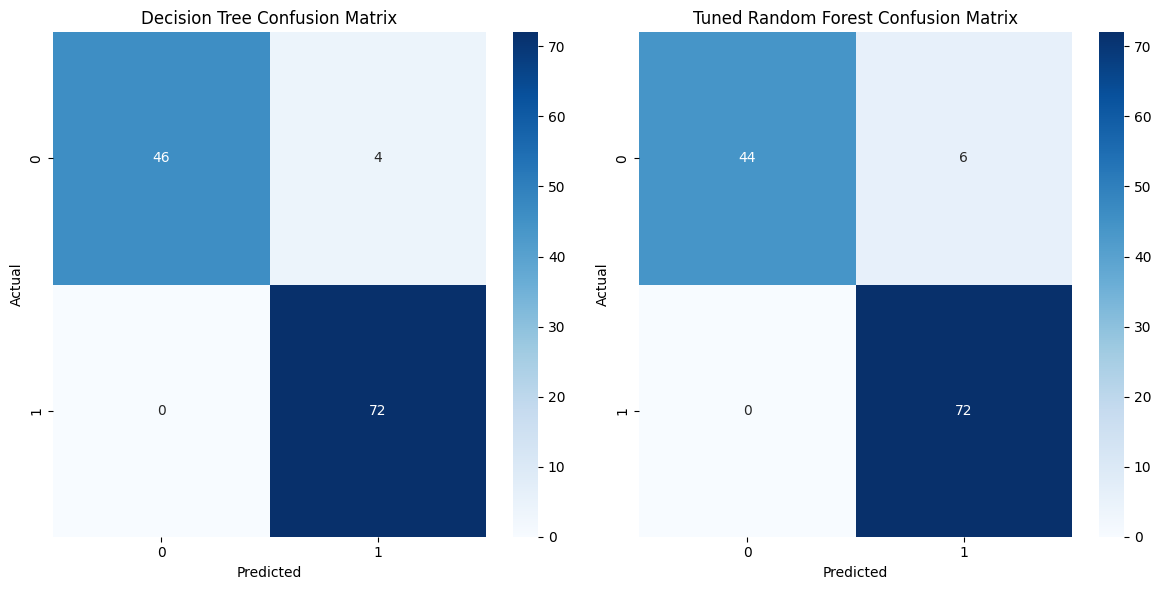


Best Parameters for Random Forest:
{'bootstrap': True, 'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset from CSV
df = pd.read_csv("/content/heart_disease_data.csv")

# Print the first few rows to inspect the dataset
print("Dataset preview:")
print(df.head())

# Print column names to verify if there are any discrepancies
print("Column Names:")
print(df.columns)

# Optional: If needed, you can rename columns or perform any preprocessing here
# For example, handle missing values
df.fillna(df.mean(), inplace=True)  # You can also use other strategies like median or mode

# Define features (X) and target variable (y)
X = df.drop('target', axis=1)  # Assuming the target column is 'target'
y = df['target']  # Assuming the target column is 'target'

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the models
decision_tree = DecisionTreeClassifier(random_state=42)
random_forest = RandomForestClassifier(random_state=42)

# Train the Decision Tree model
decision_tree.fit(X_train, y_train)

# Train the Random Forest model
random_forest.fit(X_train, y_train)

# Make predictions
y_pred_dt = decision_tree.predict(X_test)
y_pred_rf = random_forest.predict(X_test)

# Hyperparameter tuning for Random Forest using GridSearchCV
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

grid_search = GridSearchCV(estimator=random_forest, param_grid=param_grid, cv=5, verbose=2, n_jobs=-1)
grid_search.fit(X_train, y_train)

# Get the best parameters and the best score
best_rf_model = grid_search.best_estimator_
best_rf_accuracy = grid_search.best_score_

# Evaluate the Decision Tree model
print("\nDecision Tree Classifier Evaluation:")
accuracy_dt = accuracy_score(y_test, y_pred_dt)
print(f"Decision Tree Accuracy: {accuracy_dt}")
print("Classification Report (Decision Tree):")
print(classification_report(y_test, y_pred_dt))
print("Confusion Matrix (Decision Tree):")
print(confusion_matrix(y_test, y_pred_dt))

# Evaluate the tuned Random Forest model
y_pred_best_rf = best_rf_model.predict(X_test)
accuracy_best_rf = accuracy_score(y_test, y_pred_best_rf)

print("\nBest Random Forest Classifier Evaluation (After Hyperparameter Tuning):")
print(f"Random Forest Accuracy (Tuned): {accuracy_best_rf}")
print("Classification Report (Random Forest Tuned):")
print(classification_report(y_test, y_pred_best_rf))
print("Confusion Matrix (Random Forest Tuned):")
print(confusion_matrix(y_test, y_pred_best_rf))

# Plotting the confusion matrix for visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Decision Tree Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Decision Tree Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Tuned Random Forest Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred_best_rf), annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title('Tuned Random Forest Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

# Print Best Parameters for Random Forest
print("\nBest Parameters for Random Forest:")
print(grid_search.best_params_)
